<a href="https://colab.research.google.com/github/JayadharsiniMathiyalagan/Fundamentals-of-Machine-Learning/blob/main/FOML_EXP_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving recipes_muffins_cupcakes.csv to recipes_muffins_cupcakes (1).csv
Columns: Index(['Type', 'Flour', 'Milk', 'Sugar', 'Butter', 'Egg', 'Baking_Powder',
       'Vanilla', 'Salt'],
      dtype='object')
     Type  Flour  Milk  Sugar  Butter  Egg  Baking_Powder  Vanilla  Salt
0  Muffin     55    28      3       7    5              2        0     0
1  Muffin     47    24     12       6    9              1        0     0
2  Muffin     47    23     18       6    4              1        0     0
3  Muffin     45    11     17      17    8              1        0     0
4  Muffin     50    25     12       6    5              2        1     0


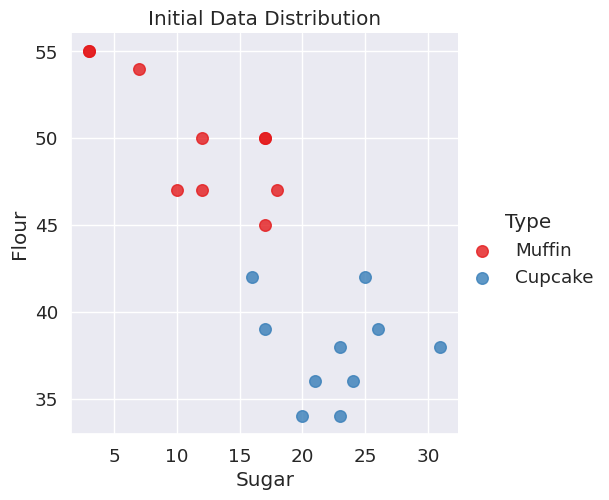

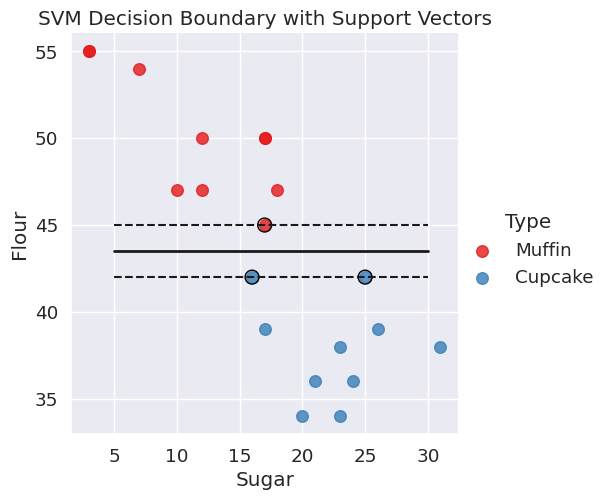

Predictions: [0 1 0 0]

Confusion Matrix:

[[2 0]
 [1 1]]

Classification Report:

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



In [1]:
# ==============================
# STEP 1: Upload Dataset
# ==============================
from google.colab import files
uploaded = files.upload()

# ==============================
# STEP 2: Import Libraries
# ==============================
import numpy as np
import pandas as pd
from sklearn import svm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=1.2)

# ==============================
# STEP 3: Load Dataset
# ==============================
recipes = pd.read_csv('recipes_muffins_cupcakes.csv')

# Clean column names (fix spaces like "Baking Powder")
recipes.columns = recipes.columns.str.strip().str.replace(' ', '_')

print("Columns:", recipes.columns)
print(recipes.head())

# ==============================
# STEP 4: Ensure Numeric Data
# ==============================
recipes['Sugar'] = recipes['Sugar'].astype(float)
recipes['Flour'] = recipes['Flour'].astype(float)

# ==============================
# STEP 5: Plot Initial Data
# ==============================
sns.lmplot(x='Sugar', y='Flour',
           data=recipes,
           hue='Type',
           palette='Set1',
           fit_reg=False,
           scatter_kws={"s": 70})

plt.title("Initial Data Distribution")
plt.show()

# ==============================
# STEP 6: Prepare Data
# ==============================
sugar_flour = recipes[['Sugar', 'Flour']].values
type_label = np.where(recipes['Type'] == 'Muffin', 0, 1)

# ==============================
# STEP 7: Train SVM Model
# ==============================
model = svm.SVC(kernel='linear')
model.fit(sugar_flour, type_label)

# ==============================
# STEP 8: Decision Boundary
# ==============================
w = model.coef_[0]
a = -w[0] / w[1]

xx = np.linspace(5, 30)
yy = a * xx - (model.intercept_[0] / w[1])

# ==============================
# STEP 9: Support Vector Boundaries
# ==============================
b = model.support_vectors_[0]
yy_down = a * xx + (b[1] - a * b[0])

b = model.support_vectors_[-1]
yy_up = a * xx + (b[1] - a * b[0])

# ==============================
# STEP 10: Plot Decision Boundary
# ==============================
sns.lmplot(x='Sugar', y='Flour',
           data=recipes,
           hue='Type',
           palette='Set1',
           fit_reg=False,
           scatter_kws={"s": 70})

plt.plot(xx, yy, 'k-', linewidth=2)
plt.plot(xx, yy_down, 'k--')
plt.plot(xx, yy_up, 'k--')

plt.scatter(model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=100, facecolors='none', edgecolors='black')

plt.title("SVM Decision Boundary with Support Vectors")
plt.show()

# ==============================
# STEP 11: Import Evaluation Tools
# ==============================
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# ==============================
# STEP 12: Split Dataset
# ==============================
x_train, x_test, y_train, y_test = train_test_split(
    sugar_flour, type_label, test_size=0.2, random_state=42)

# ==============================
# STEP 13: Train New Model
# ==============================
model1 = svm.SVC(kernel='linear')
model1.fit(x_train, y_train)

# ==============================
# STEP 14: Prediction
# ==============================
pred = model1.predict(x_test)

# ==============================
# STEP 15: Evaluation
# ==============================
print("Predictions:", pred)

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, pred))

print("\nClassification Report:\n")
print(classification_report(y_test, pred))